In [3]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
import matplotlib.pyplot as plt
from google.cloud import bigquery
from google.oauth2 import service_account

In [5]:
credentials = service_account.Credentials.from_service_account_file(
    '../credentials/gcp_credentials.json'
)
client = bigquery.Client(credentials=credentials, project='nhs-dna-analytics')

# Pull mode level data
query = """
SELECT
    appointment_mode,
    appointment_status,
    SUM(appointment_count) as total
FROM `nhs-dna-analytics.analytics.appointments_clean`
WHERE appointment_mode IN ('face_to_face', 'telephone')
GROUP BY appointment_mode, appointment_status
"""

df = client.query(query).to_dataframe()
print(df)

  appointment_mode appointment_status     total
0        telephone           attended  21419221
1        telephone                dna    623389
2     face_to_face                dna   3916245
3     face_to_face           attended  58318921


In [6]:
# Extract counts
ftf_dna = int(df[(df['appointment_mode']=='face_to_face') & 
                  (df['appointment_status']=='dna')]['total'].values[0])
ftf_attended = int(df[(df['appointment_mode']=='face_to_face') & 
                       (df['appointment_status']=='attended')]['total'].values[0])
tel_dna = int(df[(df['appointment_mode']=='telephone') & 
                  (df['appointment_status']=='dna')]['total'].values[0])
tel_attended = int(df[(df['appointment_mode']=='telephone') & 
                       (df['appointment_status']=='attended')]['total'].values[0])

ftf_total = ftf_dna + ftf_attended
tel_total = tel_dna + tel_attended

ftf_rate = ftf_dna / ftf_total
tel_rate = tel_dna / tel_total

print(f"Face-to-face DNA rate: {ftf_rate:.2%} ({ftf_dna:,} DNA from {ftf_total:,})")
print(f"Telephone DNA rate: {tel_rate:.2%} ({tel_dna:,} DNA from {tel_total:,})")
print(f"Absolute difference: {abs(ftf_rate - tel_rate):.2%}")

Face-to-face DNA rate: 6.29% (3,916,245 DNA from 62,235,166)
Telephone DNA rate: 2.83% (623,389 DNA from 22,042,610)
Absolute difference: 3.46%


In [7]:
# Two-proportion z-test
count = np.array([ftf_dna, tel_dna])
nobs = np.array([ftf_total, tel_total])
stat, pvalue = proportions_ztest(count, nobs)

print(f"\nZ-statistic: {stat:.4f}")
print(f"P-value: {pvalue:.6f}")
print(f"Statistically significant (p < 0.05): {pvalue < 0.05}")


Z-statistic: 619.1687
P-value: 0.000000
Statistically significant (p < 0.05): True


In [8]:
# Power analysis
effect_size = abs(ftf_rate - tel_rate)
power_analysis = NormalIndPower()
sample_size_needed = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.8,
    alpha=0.05
)
print(f"\nRequired sample size per group for 80% power: {sample_size_needed:.0f}")
print(f"Actual sample sizes: Face-to-face={ftf_total:,}, Telephone={tel_total:,}")
print(f"Test is well-powered: {min(ftf_total, tel_total) > sample_size_needed}")


Required sample size per group for 80% power: 13078
Actual sample sizes: Face-to-face=62,235,166, Telephone=22,042,610
Test is well-powered: True


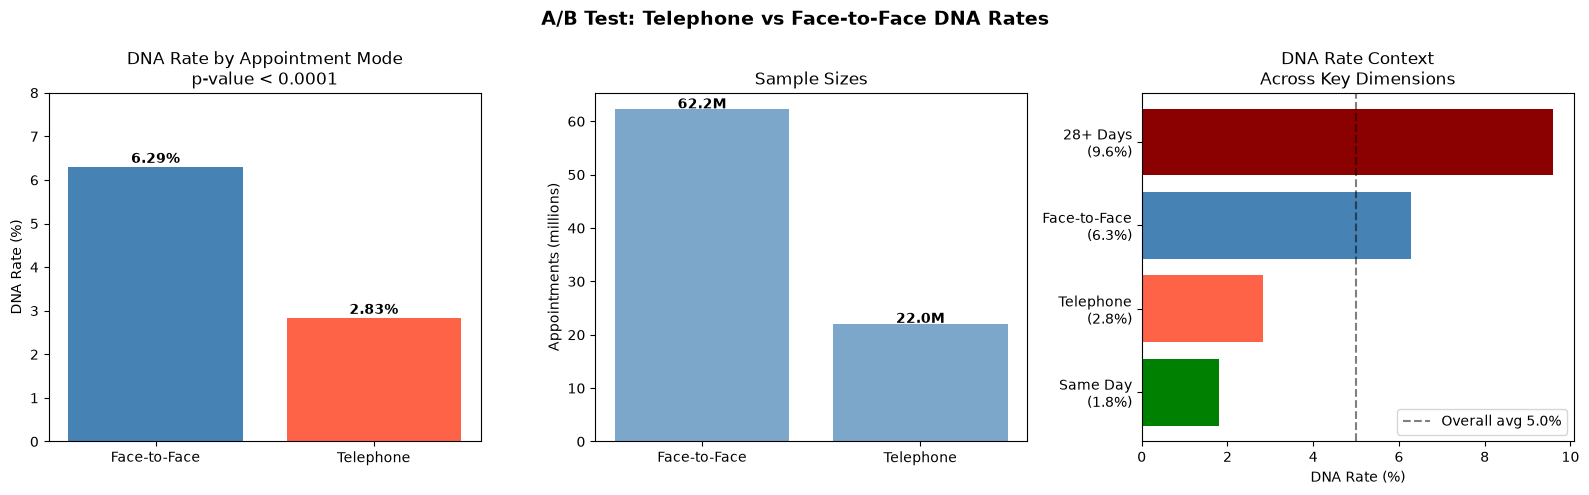


Conclusion:
Face-to-face appointments have a 3.46% higher DNA rate
than telephone appointments (6.29% vs 2.83%).
This difference is statistically significant (p < 0.0001)
with a sample size of 84,277,776 appointments.
Switching high-risk appointments to telephone mode could
substantially reduce wasted appointment slots.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('A/B Test: Telephone vs Face-to-Face DNA Rates', 
             fontsize=14, fontweight='bold')

# DNA rate comparison
bars = axes[0].bar(['Face-to-Face', 'Telephone'],
                    [ftf_rate * 100, tel_rate * 100],
                    color=['steelblue', 'tomato'])
axes[0].set_ylabel('DNA Rate (%)')
axes[0].set_title(f'DNA Rate by Appointment Mode\np-value < 0.0001')
axes[0].set_ylim(0, 8)
for bar, val in zip(bars, [ftf_rate * 100, tel_rate * 100]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                 f'{val:.2f}%', ha='center', fontweight='bold')

# Sample sizes
axes[1].bar(['Face-to-Face', 'Telephone'],
             [ftf_total/1e6, tel_total/1e6],
             color='steelblue', alpha=0.7)
axes[1].set_ylabel('Appointments (millions)')
axes[1].set_title('Sample Sizes')
for i, val in enumerate([ftf_total/1e6, tel_total/1e6]):
    axes[1].text(i, val + 0.2, f'{val:.1f}M', ha='center', fontweight='bold')

# Effect size context
categories = ['Same Day\n(1.8%)', 'Telephone\n(2.8%)', 
              'Face-to-Face\n(6.3%)', '28+ Days\n(9.6%)']
values = [1.8, 2.83, 6.29, 9.6]
colors = ['green', 'tomato', 'steelblue', 'darkred']
axes[2].barh(categories, values, color=colors)
axes[2].set_xlabel('DNA Rate (%)')
axes[2].set_title('DNA Rate Context\nAcross Key Dimensions')
axes[2].axvline(x=5.0, color='black', linestyle='--', alpha=0.5, label='Overall avg 5.0%')
axes[2].legend()

plt.tight_layout()
plt.savefig('../screenshots/ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nConclusion:")
print(f"Face-to-face appointments have a {abs(ftf_rate-tel_rate):.2%} higher DNA rate")
print(f"than telephone appointments (6.29% vs 2.83%).")
print(f"This difference is statistically significant (p < 0.0001)")
print(f"with a sample size of {ftf_total+tel_total:,} appointments.")
print(f"Switching high-risk appointments to telephone mode could")
print(f"substantially reduce wasted appointment slots.")